In [1]:
print("Hello")

Hello


Here’s a **clear, practical comparison**—especially relevant for production code and automation.

***

## `print()` vs `logging` in Python

### 1️⃣ Purpose

**`print()`**

*   Used for **quick debugging**
*   Writes output directly to the console
*   Not suitable for real applications

**`logging`**

*   Used for **application diagnostics and monitoring**
*   Designed for **production, automation, and large codebases**

***

### 2️⃣ Control & Levels

**`print()`**

*   No severity levels
*   You can’t distinguish info vs errors

```python
print("Something went wrong")
```

**`logging`**

*   Supports log levels:
    *   `DEBUG`
    *   `INFO`
    *   `WARNING`
    *   `ERROR`
    *   `CRITICAL`

```python
logger.info("Service started")
logger.error("Connection failed")
```

***

### 3️⃣ Output Destination

**`print()`**

*   Only prints to the console (stdout)

**`logging`**

*   Can write to:
    *   Console
    *   Log files
    *   Rotating files
    *   Remote log servers (Splunk, Azure Monitor, etc.)

```python
logging.basicConfig(filename="app.log")
```

***

### 4️⃣ Configuration & Filtering

**`print()`**

*   Cannot be turned off without removing code

**`logging`**

*   Can be enabled/disabled via config
*   No code changes needed

```python
logging.basicConfig(level=logging.WARNING)
```

✅ `INFO` logs are ignored  
✅ `ERROR` logs still show

***

### 5️⃣ Context & Traceability

**`print()`**

*   No metadata
*   Hard to trace source

**`logging`**

*   Automatically includes:
    *   Module name
    *   Timestamp
    *   Log level
    *   Line number (optional)

Example:

    2026-03-12 15:21:10 network_utils ERROR Interface down

***

### 6️⃣ Performance & Scalability

**`print()`**

*   Slows down large applications
*   Clutters output

**`logging`**

*   Efficient
*   Thread-safe
*   Scales well in multi-module projects

***

## Quick Summary Table

| Feature                     | `print()`      | `logging`               |
| --------------------------- | -------------- | ----------------------- |
| Use case                    | Debugging only | Production & automation |
| Log levels                  | ❌ No           | ✅ Yes                   |
| Output control              | ❌ No           | ✅ Yes                   |
| File logging                | ❌ No           | ✅ Yes                   |
| Disable without code change | ❌ No           | ✅ Yes                   |
| Best practice               | ❌ No           | ✅ Yes                   |

***

## One‑line takeaway (manager‑ready)

> `print()` is for quick debugging, while `logging` is a structured, configurable, and production‑ready way to track application behavior.

If you want, I can also show:

*   ✅ When to use each log level
*   ✅ A **minimal logging setup for network automation**
*   ✅ How logging works across multiple Python files


In [2]:
import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(name)s | %(message)s"
)

logger = logging.getLogger(__name__)

print("Starting script...")          # simple console output
logger.info("Starting script...")    # structured log


2026-03-12 15:42:27,964 | INFO | __main__ | Starting script...


Starting script...


In [5]:
import logging

logging.basicConfig(
    level=logging.WARNING,
    format="%(asctime)s | %(levelname)s | %(name)s | %(message)s"
)

logger = logging.getLogger(__name__)

print("Starting script...")          # simple console output
logger.info("Starting script...")    # structured log


2026-03-12 15:45:00,835 | INFO | __main__ | Starting script...


Starting script...


In [4]:
import logging

logging.basicConfig(
    level=logging.WARNING,
    format="%(asctime)s | %(levelname)s | %(name)s | %(message)s"
)

logger = logging.getLogger(__name__)

print("Starting script...")          # simple console output
logger.warning("Starting script...")    # structured log


2026-03-12 15:44:46,857 | WARNING | __main__ | Starting script...


Starting script...


In [7]:
import logging

logging.basicConfig(
    level=logging.WARNING,   # ⬅️ changed from INFO to WARNING
    format="%(asctime)s | %(levelname)s | %(name)s | %(message)s"
)

logger = logging.getLogger(__name__)

print("Starting script...")                 # ✅ ALWAYS prints
logger.info("Starting script (INFO)")       # ❌ NOT shown
logger.warning("Low disk space warning")    # ✅ SHOWN
logger.error("Disk read failed")             # ✅ SHOWN

2026-03-12 15:45:39,242 | INFO | __main__ | Starting script (INFO)
2026-03-12 15:45:39,244 | WARNING | __main__ | Low disk space warning
2026-03-12 15:45:39,245 | ERROR | __main__ | Disk read failed


Starting script...


Here’s a **clean WARNING‑level example** that shows exactly what disappears when you change the log level.

### ✅ WARNING example (side‑by‑side with print)

```python
import logging

logging.basicConfig(
    level=logging.WARNING,   # ⬅️ changed from INFO to WARNING
    format="%(asctime)s | %(levelname)s | %(name)s | %(message)s"
)

logger = logging.getLogger(__name__)

print("Starting script...")                 # ✅ ALWAYS prints
logger.info("Starting script (INFO)")       # ❌ NOT shown
logger.warning("Low disk space warning")    # ✅ SHOWN
logger.error("Disk read failed")             # ✅ SHOWN
```

### ✅ Output you will see

    Starting script...
    2026-03-12 15:44:20 | WARNING | __main__ | Low disk space warning
    2026-03-12 15:44:20 | ERROR   | __main__ | Disk read failed

### 🔑 Key takeaway (important for automation & tests)

*   `print()` → **always shows**
*   `logger.info()` → hidden when level = `WARNING`
*   `logger.warning()` and above → **always shown**

### ✅ One‑line summary (manager‑ready)

> Setting logging level to WARNING hides INFO logs but still captures important warnings and errors, while print() always outputs.

If you want, I can also show:

*   ✅ how this behaves in **pytest**
*   ✅ logging to a **file**
*   ✅ real‑world **network automation** example (device down, retry, fail)

Just tell me 👍


In [8]:
import logging

logging.basicConfig(
    level=logging.WARNING,
    format="%(asctime)s | %(levelname)s | %(name)s | %(message)s",
    force=True
)

logger = logging.getLogger(__name__)

logger.info("This INFO should NOT show")
logger.warning("This WARNING should show")
logger.error("This ERROR should show")

2026-03-12 15:47:27,443 | WARNING | __main__ | This WARNING should show
2026-03-12 15:47:27,444 | ERROR | __main__ | This ERROR should show


In [10]:
!pip install pytest

Defaulting to user installation because normal site-packages is not writeable

   -------------------------- ------------- 2/3 [pytest]
   -------------------------- ------------- 2/3 [pytest]
   -------------------------- ------------- 2/3 [pytest]
   -------------------------- ------------- 2/3 [pytest]
   -------------------------- ------------- 2/3 [pytest]
   ---------------------------------------- 3/3 [pytest]




[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\v-yaalam\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [12]:
import logging
import pytest

logger = logging.getLogger(__name__)

pytestmark = [pytest.mark.ingress, pytest.mark.steering]

def test_route_programming():
    logger.info("checking route programming")
    assert True

https://learn.microsoft.com/en-us/azure/developer/python/sdk/azure-sdk-logging

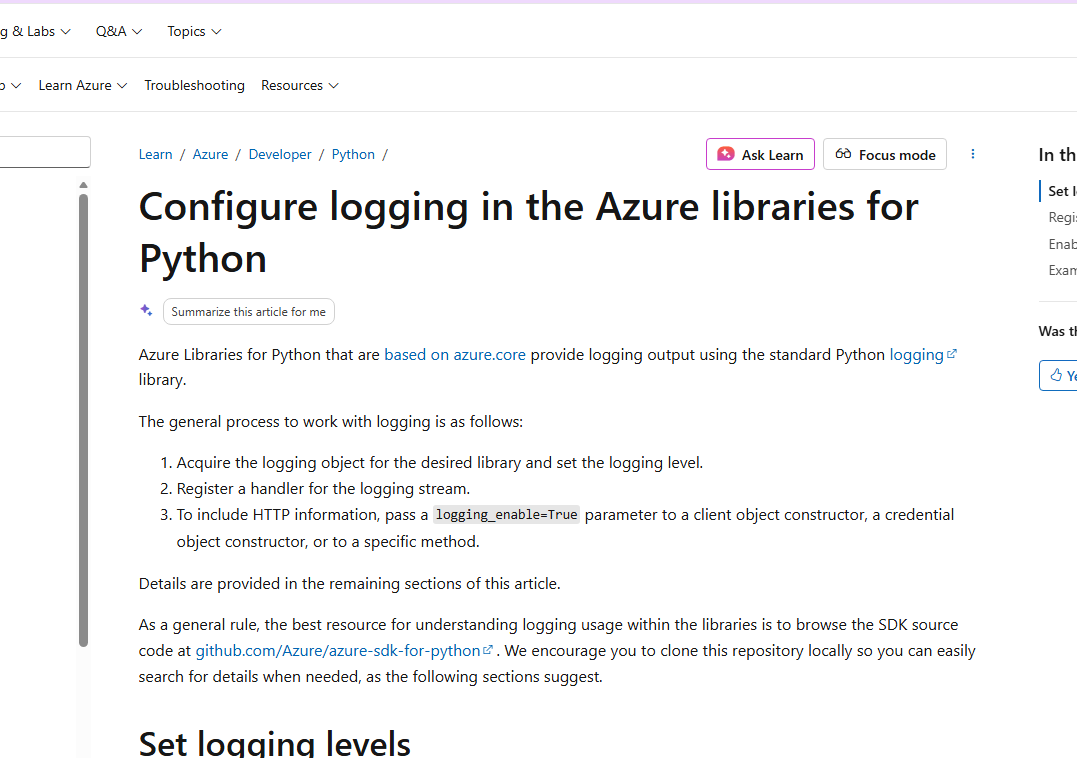

In [13]:
import logging

# ...

# Acquire the logger for a library (azure.mgmt.resource in this example)
logger = logging.getLogger('azure.mgmt.resource')

# Set the desired logging level
logger.setLevel(logging.DEBUG)

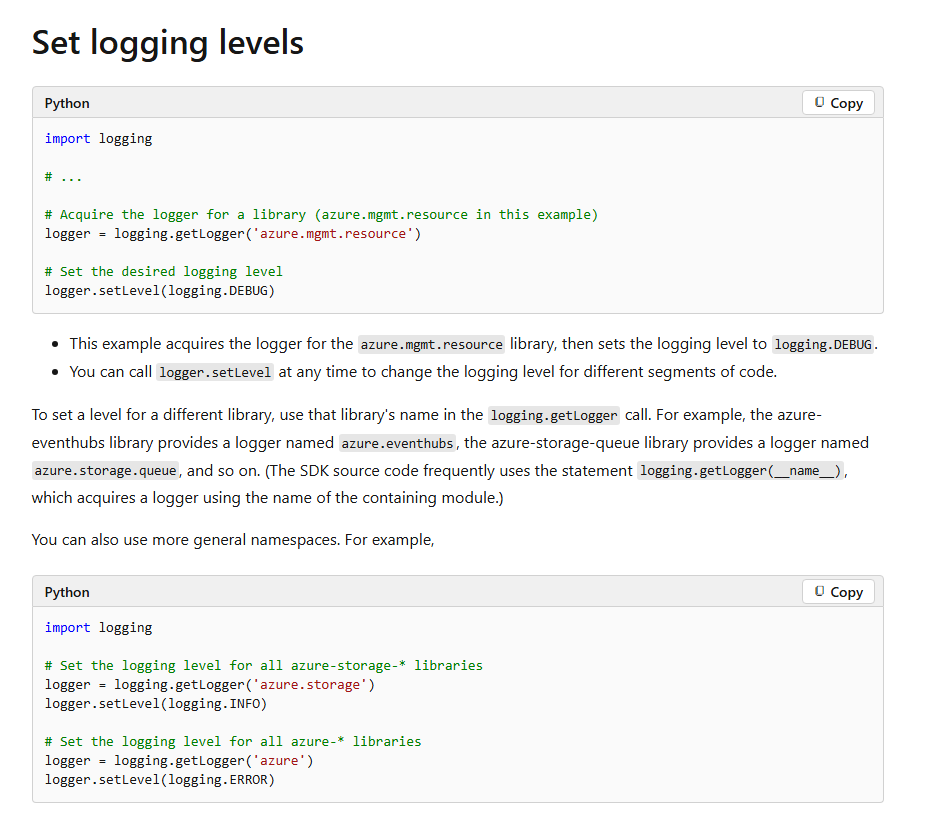

In [14]:
import logging

# Set the logging level for all azure-storage-* libraries
logger = logging.getLogger('azure.storage')
logger.setLevel(logging.INFO)

# Set the logging level for all azure-* libraries
logger = logging.getLogger('azure')
logger.setLevel(logging.ERROR)

In [15]:
print(
    f"Logger enabled for ERROR={logger.isEnabledFor(logging.ERROR)}, "
    f"WARNING={logger.isEnabledFor(logging.WARNING)}, "
    f"INFO={logger.isEnabledFor(logging.INFO)}, "
    f"DEBUG={logger.isEnabledFor(logging.DEBUG)}"
)

Logger enabled for ERROR=True, WARNING=False, INFO=False, DEBUG=False


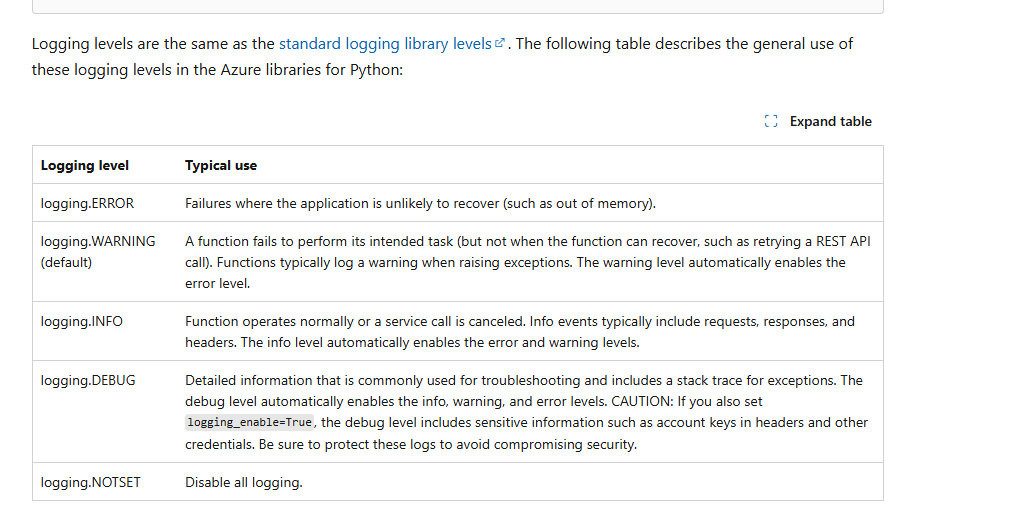

https://docs.python.org/3/library/logging.html


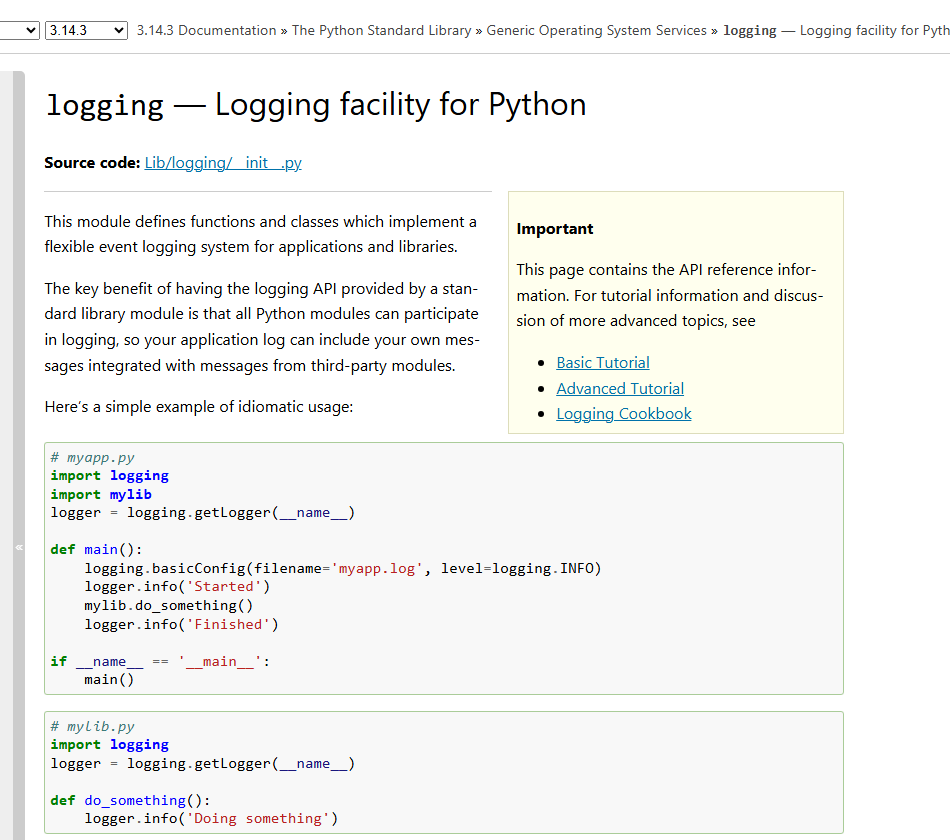


In [17]:
!pip install mylib

Defaulting to user installation because normal site-packages is not writeable
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for mylib: filename=mylib-0.0.1-py3-none-any.whl size=1024 sha256=4e4d341cfd6a46429740802c632f1abf402763ea448c7f428406533496405ab0
  Stored in directory: c:\users\v-yaalam\appdata\local\packages\pythonsoftwarefoundation.python.3.13_qbz5n2kfra8p0\localcache\local\pip\cache\wheels\b6\13\3c\a36297b23bc5d715095a48206b5937d397609dd61b73d33f4e
Successfully built mylib



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\v-yaalam\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [20]:
# myapp.py
import logging
import mylib
logger = logging.getLogger(__name__)

def main():
    logging.basicConfig(filename='myapp.log', level=logging.INFO)
    logger.info('Started')
    mylib.do_something()
    logger.info('Finished')

if __name__ == '__main__':
    main()

ModuleNotFoundError: No module named 'mylib'

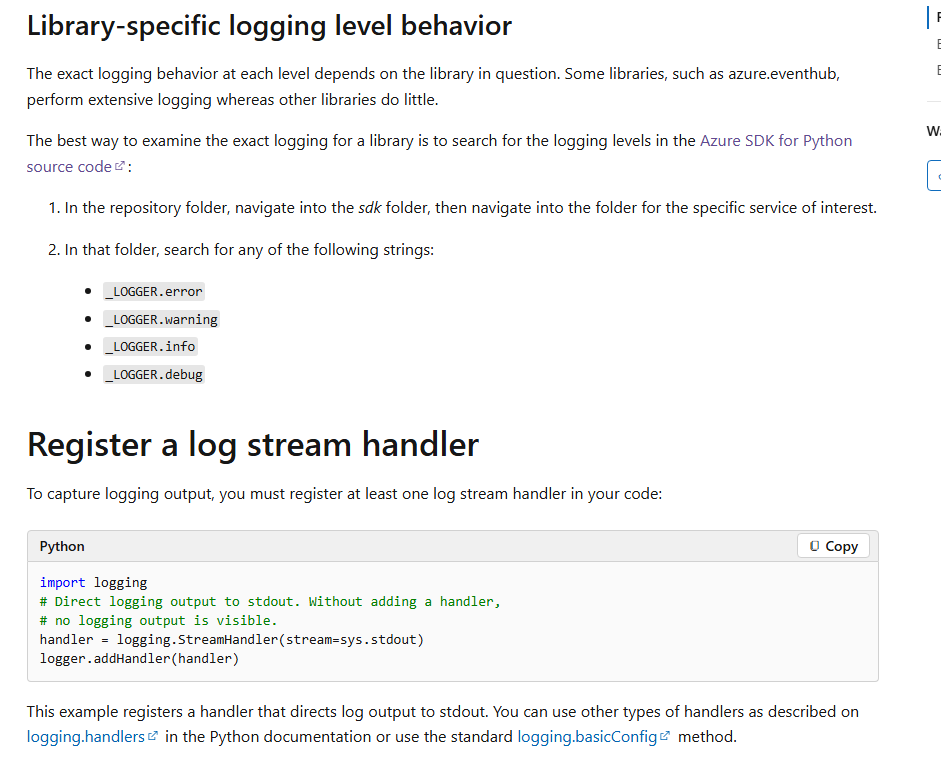

In [23]:
!pip install sys

Defaulting to user installation because normal site-packages is not writeable


ERROR: Could not find a version that satisfies the requirement sys (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\v-yaalam\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for sys


In [24]:
import logging
# Direct logging output to stdout. Without adding a handler,
# no logging output is visible.
handler = logging.StreamHandler(stream=sys.stdout)
logger.addHandler(handler)

NameError: name 'sys' is not defined